# Heatwave Analysis — Part 2: Detect & Visualise

Loads daily Tmax for both scenarios produced by Part 1 and finds the
5 strongest heatwaves in each.

**Heatwave definition:** ≥ 3 consecutive days where daily Tmax **both**
exceeds the **90th percentile of summer (JJA) Tmax** of that scenario's
own record **and** is ≥ 27 °C.

**Ranking:** cumulative surplus above the percentile threshold (°C·days).

## Overview

Analyses CORDEX EUR-11 regional climate model output for two locations in Estonia
across three scenarios. Functions are defined in **`heatwave_utils.py`**.

| Scenario | Period | Pathway |
|---|---|---|
| Historical | 1971–1990 | observed forcing |
| RCP 4.5 | 2071–2100 | moderate mitigation |
| RCP 8.5 | 2071–2100 | high-emission baseline |

**Heatwave definition:** ≥ 3 consecutive summer days where daily Tmax exceeds the
scenario's own 90th-pct JJA Tmax **and** ≥ ABS_THRESHOLD (default 20 °C).
Events ranked by cumulative surplus above the percentile threshold (°C·days).

**Sections:**
1. Load data
2. Detect heatwaves — threshold, counts, top-5 table per location × scenario
3. Visualise — full time-series overview; per-event zoom-in panels
4. Climate statistics — 28-metric summary table
5. Heatwave scatter — mean Tmin vs mean Tmax, point size = duration

## Variables

Daily aggregates extracted from CORDEX EUR-11 NetCDF files.
Source files are named `{var}_EUR-11_*_{scenario}_*.nc`; raw temperatures are in Kelvin and converted to °C on extraction.

| CSV column | CORDEX abbr. | Full name | Unit | Aggregation |
|---|---|---|---|---|
| `tmax_C` | `tas` | Near-Surface Air Temperature | °C | daily max |
| `tmean_C` | `tas` | Near-Surface Air Temperature | °C | daily mean |
| `tmin_C` | `tas` | Near-Surface Air Temperature | °C | daily min |
| `hurs_mean` | `hurs` | Near-Surface Relative Humidity | % | daily mean |
| `sfcWind_mean` | `sfcWind` | Near-Surface Wind Speed | m s⁻¹ | daily mean |
| `clt_mean` | `clt` | Total Cloud Fraction | % | daily mean |

In [1]:
import json
import numpy as np
from heatwave_utils import detect_heatwaves, climate_stats
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ABS_THRESHOLD = 20.0  # °C — absolute floor for a heatwave day

SCENARIOS = {
    'historical': {'label': 'Historical', 'color': 'steelblue'},
    'rcp45':      {'label': 'RCP 4.5',    'color': 'tomato'},
    'rcp85':      {'label': 'RCP 8.5',    'color': 'darkred'},
}

LOCATIONS = {
    'tallinn':   {'label': 'Tallinn',         'color': 'steelblue'},
    'c_estonia': {'label': 'Central Estonia', 'color': 'forestgreen'},
}

## 1. Load data

In [2]:
with open('tallinn_point_meta.json') as f:
    meta = json.load(f)

for loc_name, loc_cfg in LOCATIONS.items():
    m = meta[loc_name]
    loc_cfg['point_lat'] = m['point_lat']
    loc_cfg['point_lon'] = m['point_lon']
    loc_cfg['dist_km']   = m['dist_km']
    print(f"{loc_cfg['label']:20s}  {m['point_lat']:.3f}°N, {m['point_lon']:.3f}°E  "
          f"({m['dist_km']:.1f} km from target)")

Tallinn               59.441°N, 24.863°E  (6.2 km from target)
Central Estonia       58.742°N, 25.579°E  (6.5 km from target)


In [3]:
data   = {loc: {} for loc in LOCATIONS}
tmax_s = {loc: {} for loc in LOCATIONS}
tmin_s = {loc: {} for loc in LOCATIONS}

for loc_name in LOCATIONS:
    for scenario in SCENARIOS:
        df = pd.read_csv(f'{loc_name}_daily_{scenario}.csv.gz',
                         index_col='date', parse_dates=True, compression='gzip')
        data[loc_name][scenario]   = df
        tmax_s[loc_name][scenario] = df['tmax_C']
        tmin_s[loc_name][scenario] = df['tmin_C']
        print(f'{loc_name:12s} {scenario:12s}  {len(df)} days  '
              f'({df.index[0].date()} – {df.index[-1].date()})')

tallinn      historical    11323 days  (1970-01-01 – 2000-12-31)
tallinn      rcp45         10957 days  (2071-01-01 – 2100-12-31)
tallinn      rcp85         10957 days  (2071-01-01 – 2100-12-31)
c_estonia    historical    11323 days  (1970-01-01 – 2000-12-31)
c_estonia    rcp45         10957 days  (2071-01-01 – 2100-12-31)
c_estonia    rcp85         10957 days  (2071-01-01 – 2100-12-31)


## 2. Detect heatwaves

In [4]:
# detect_heatwaves is defined in heatwave_utils.py

In [5]:
results = {loc: {} for loc in LOCATIONS}

for loc_name in LOCATIONS:
    for scenario, scen_cfg in SCENARIOS.items():
        threshold, hw_df = detect_heatwaves(tmax_s[loc_name][scenario], abs_threshold=ABS_THRESHOLD)
        results[loc_name][scenario] = {'threshold': threshold, 'hw_df': hw_df}
        print(f"{LOCATIONS[loc_name]['label']:20s}  {scen_cfg['label']:12s}  "
              f"threshold={threshold:.2f} °C,  {len(hw_df)} events")

Tallinn               Historical    threshold=23.07 °C,  43 events
Tallinn               RCP 4.5       threshold=24.08 °C,  32 events
Tallinn               RCP 8.5       threshold=25.72 °C,  29 events
Central Estonia       Historical    threshold=24.65 °C,  42 events
Central Estonia       RCP 4.5       threshold=24.94 °C,  41 events
Central Estonia       RCP 8.5       threshold=26.69 °C,  43 events


In [6]:
for loc_name, loc_cfg in LOCATIONS.items():
    for scenario, scen_cfg in SCENARIOS.items():
        hw_df = results[loc_name][scenario]['hw_df']
        top5  = hw_df.head(5).copy()
        top5['start'] = top5['start'].dt.strftime('%Y-%m-%d')
        top5['end']   = top5['end'].dt.strftime('%Y-%m-%d')
        top5.columns  = ['Start', 'End', 'Duration (days)', 'Peak Tmax (°C)', 'Surplus (°C·days)']
        results[loc_name][scenario]['top5'] = top5
        print(f"=== {loc_cfg['label']} — {scen_cfg['label']} ===")
        print(top5.to_string())
        print()

=== Tallinn — Historical ===
        Start         End  Duration (days)  Peak Tmax (°C)  Surplus (°C·days)
1  1980-07-09  1980-07-18               10           35.22              54.41
2  1994-08-05  1994-08-13                9           29.80              49.96
3  1996-08-07  1996-08-16               10           30.17              41.52
4  1992-07-01  1992-07-08                8           29.25              30.48
5  1999-07-30  1999-08-03                5           32.01              28.16

=== Tallinn — RCP 4.5 ===
        Start         End  Duration (days)  Peak Tmax (°C)  Surplus (°C·days)
1  2093-07-01  2093-07-11               11           31.57              44.24
2  2073-07-25  2073-08-01                8           31.68              33.11
3  2080-07-17  2080-07-25                9           31.70              31.53
4  2093-07-16  2093-07-23                8           30.26              25.68
5  2081-07-31  2081-08-03                4           33.86              23.32

=== Tal

In [7]:
results['tallinn']['historical']['hw_df']

,start,end,duration_days,peak_T_C,surplus_Cdays
1,1980-07-09,1980-07-18,10,35.22,54.41
2,1994-08-05,1994-08-13,9,29.80,49.96
3,1996-08-07,1996-08-16,10,30.17,41.52
4,1992-07-01,1992-07-08,8,29.25,30.48
5,1999-07-30,1999-08-03,5,32.01,28.16
6,1982-08-25,1982-08-28,4,31.66,28.00
7,1982-08-17,1982-08-20,4,32.00,22.29
8,1980-08-04,1980-08-09,6,29.23,21.65
9,1999-09-01,1999-09-04,4,29.87,21.05
10,1976-07-28,1976-07-31,4,27.58,15.56


## 3. Visualise

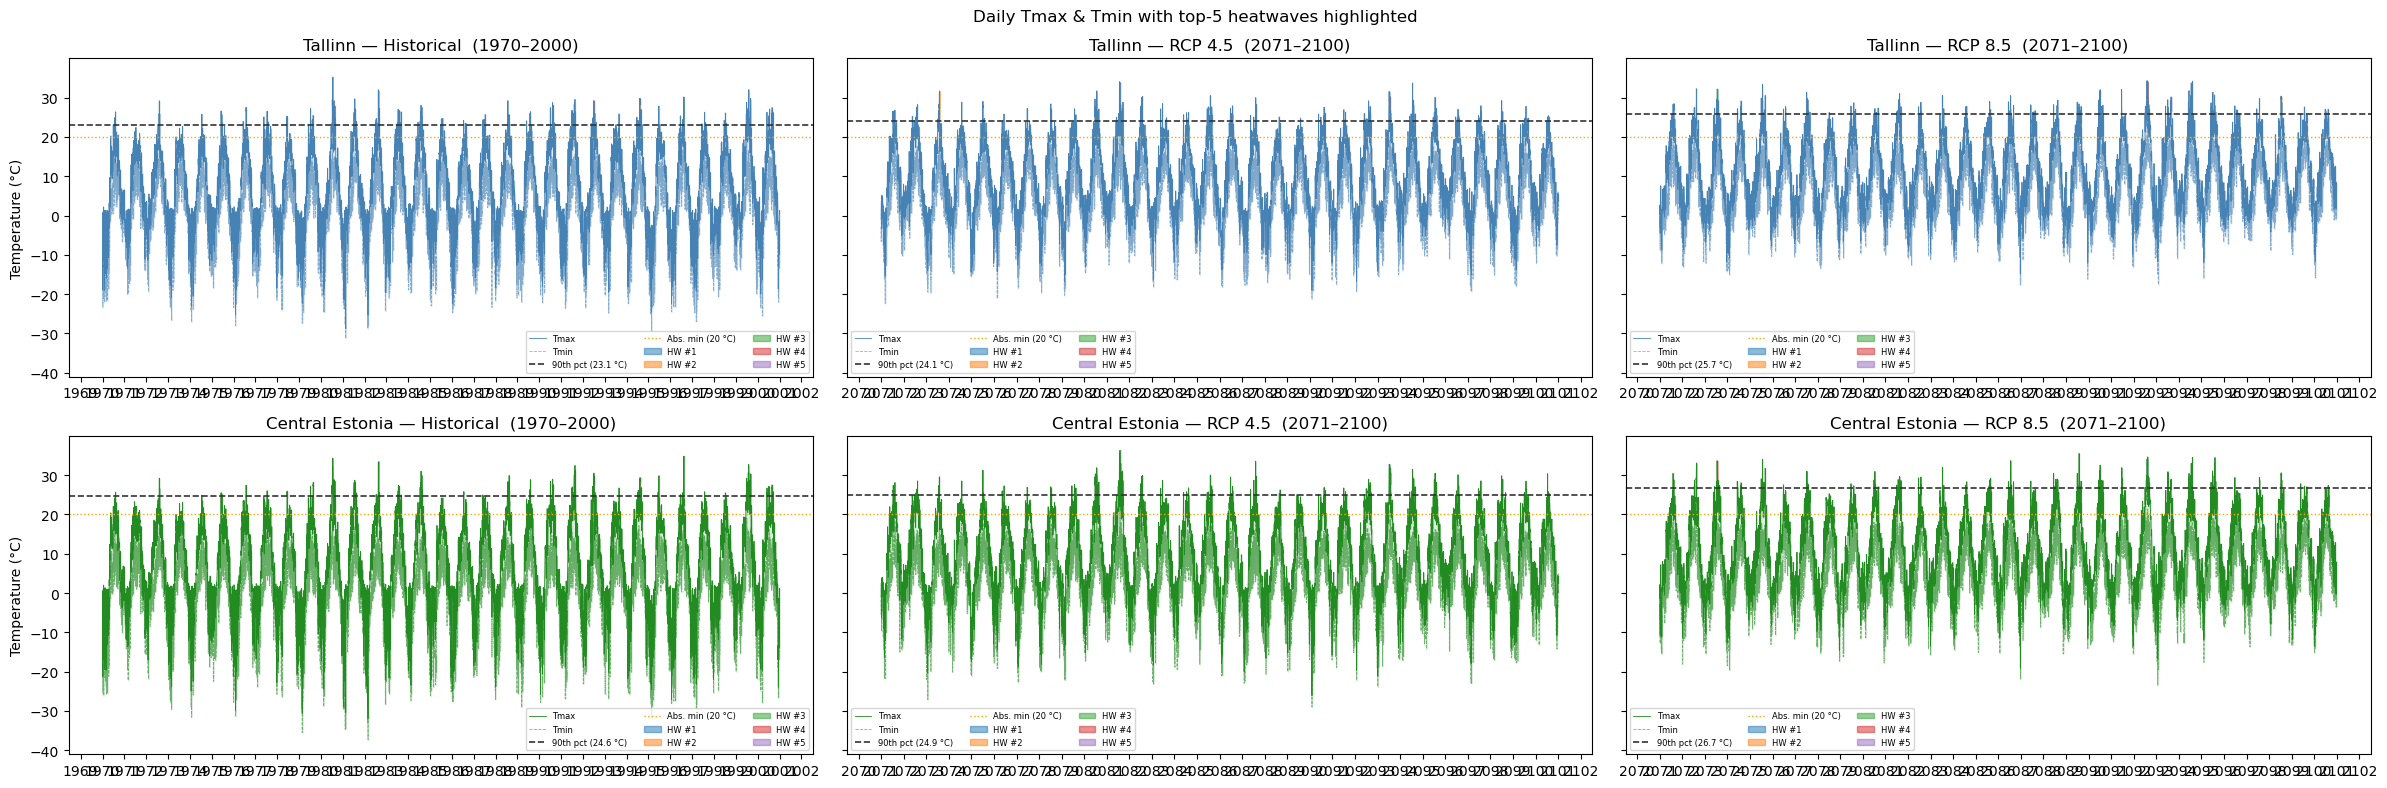

In [8]:
# 2×3 grid: rows = locations, cols = scenarios
hw_colors = plt.cm.tab10.colors
fig, axes = plt.subplots(2, 3, figsize=(24, 8), sharey=True)

for col, (scenario, scen_cfg) in enumerate(SCENARIOS.items()):
    for row, (loc_name, loc_cfg) in enumerate(LOCATIONS.items()):
        ax    = axes[row, col]
        tmax  = tmax_s[loc_name][scenario]
        tmin  = tmin_s[loc_name][scenario]
        threshold = results[loc_name][scenario]['threshold']
        hw_df     = results[loc_name][scenario]['hw_df']

        ax.fill_between(tmax.index, tmax.values, tmin.values,
                        alpha=0.15, color=loc_cfg['color'])
        ax.plot(tmax.index, tmax.values, lw=0.6, color=loc_cfg['color'], label='Tmax')
        ax.plot(tmin.index, tmin.values, lw=0.6, color=loc_cfg['color'],
                ls='--', alpha=0.6, label='Tmin')
        ax.axhline(threshold,     color='#333333', lw=1.2, ls='--',
                   label=f'90th pct ({threshold:.1f} °C)')
        ax.axhline(ABS_THRESHOLD, color='orange',  lw=1.0, ls=':',
                   label=f'Abs. min ({ABS_THRESHOLD:.0f} °C)')

        for rank, (_, hw) in enumerate(hw_df.head(5).iterrows(), start=1):
            mask = (tmax.index >= hw['start']) & (tmax.index <= hw['end'])
            ax.fill_between(tmax.index, tmax.values, threshold,
                            where=mask, alpha=0.5, color=hw_colors[rank - 1],
                            label=f'HW #{rank}')

        ax.set_title(f"{loc_cfg['label']} — {scen_cfg['label']}  "
                     f"({tmax.index[0].year}–{tmax.index[-1].year})")
        ax.set_ylabel('Temperature (°C)' if col == 0 else '')
        ax.legend(fontsize=6, ncol=3)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Daily Tmax & Tmin with top-5 heatwaves highlighted')
plt.tight_layout()
plt.show()

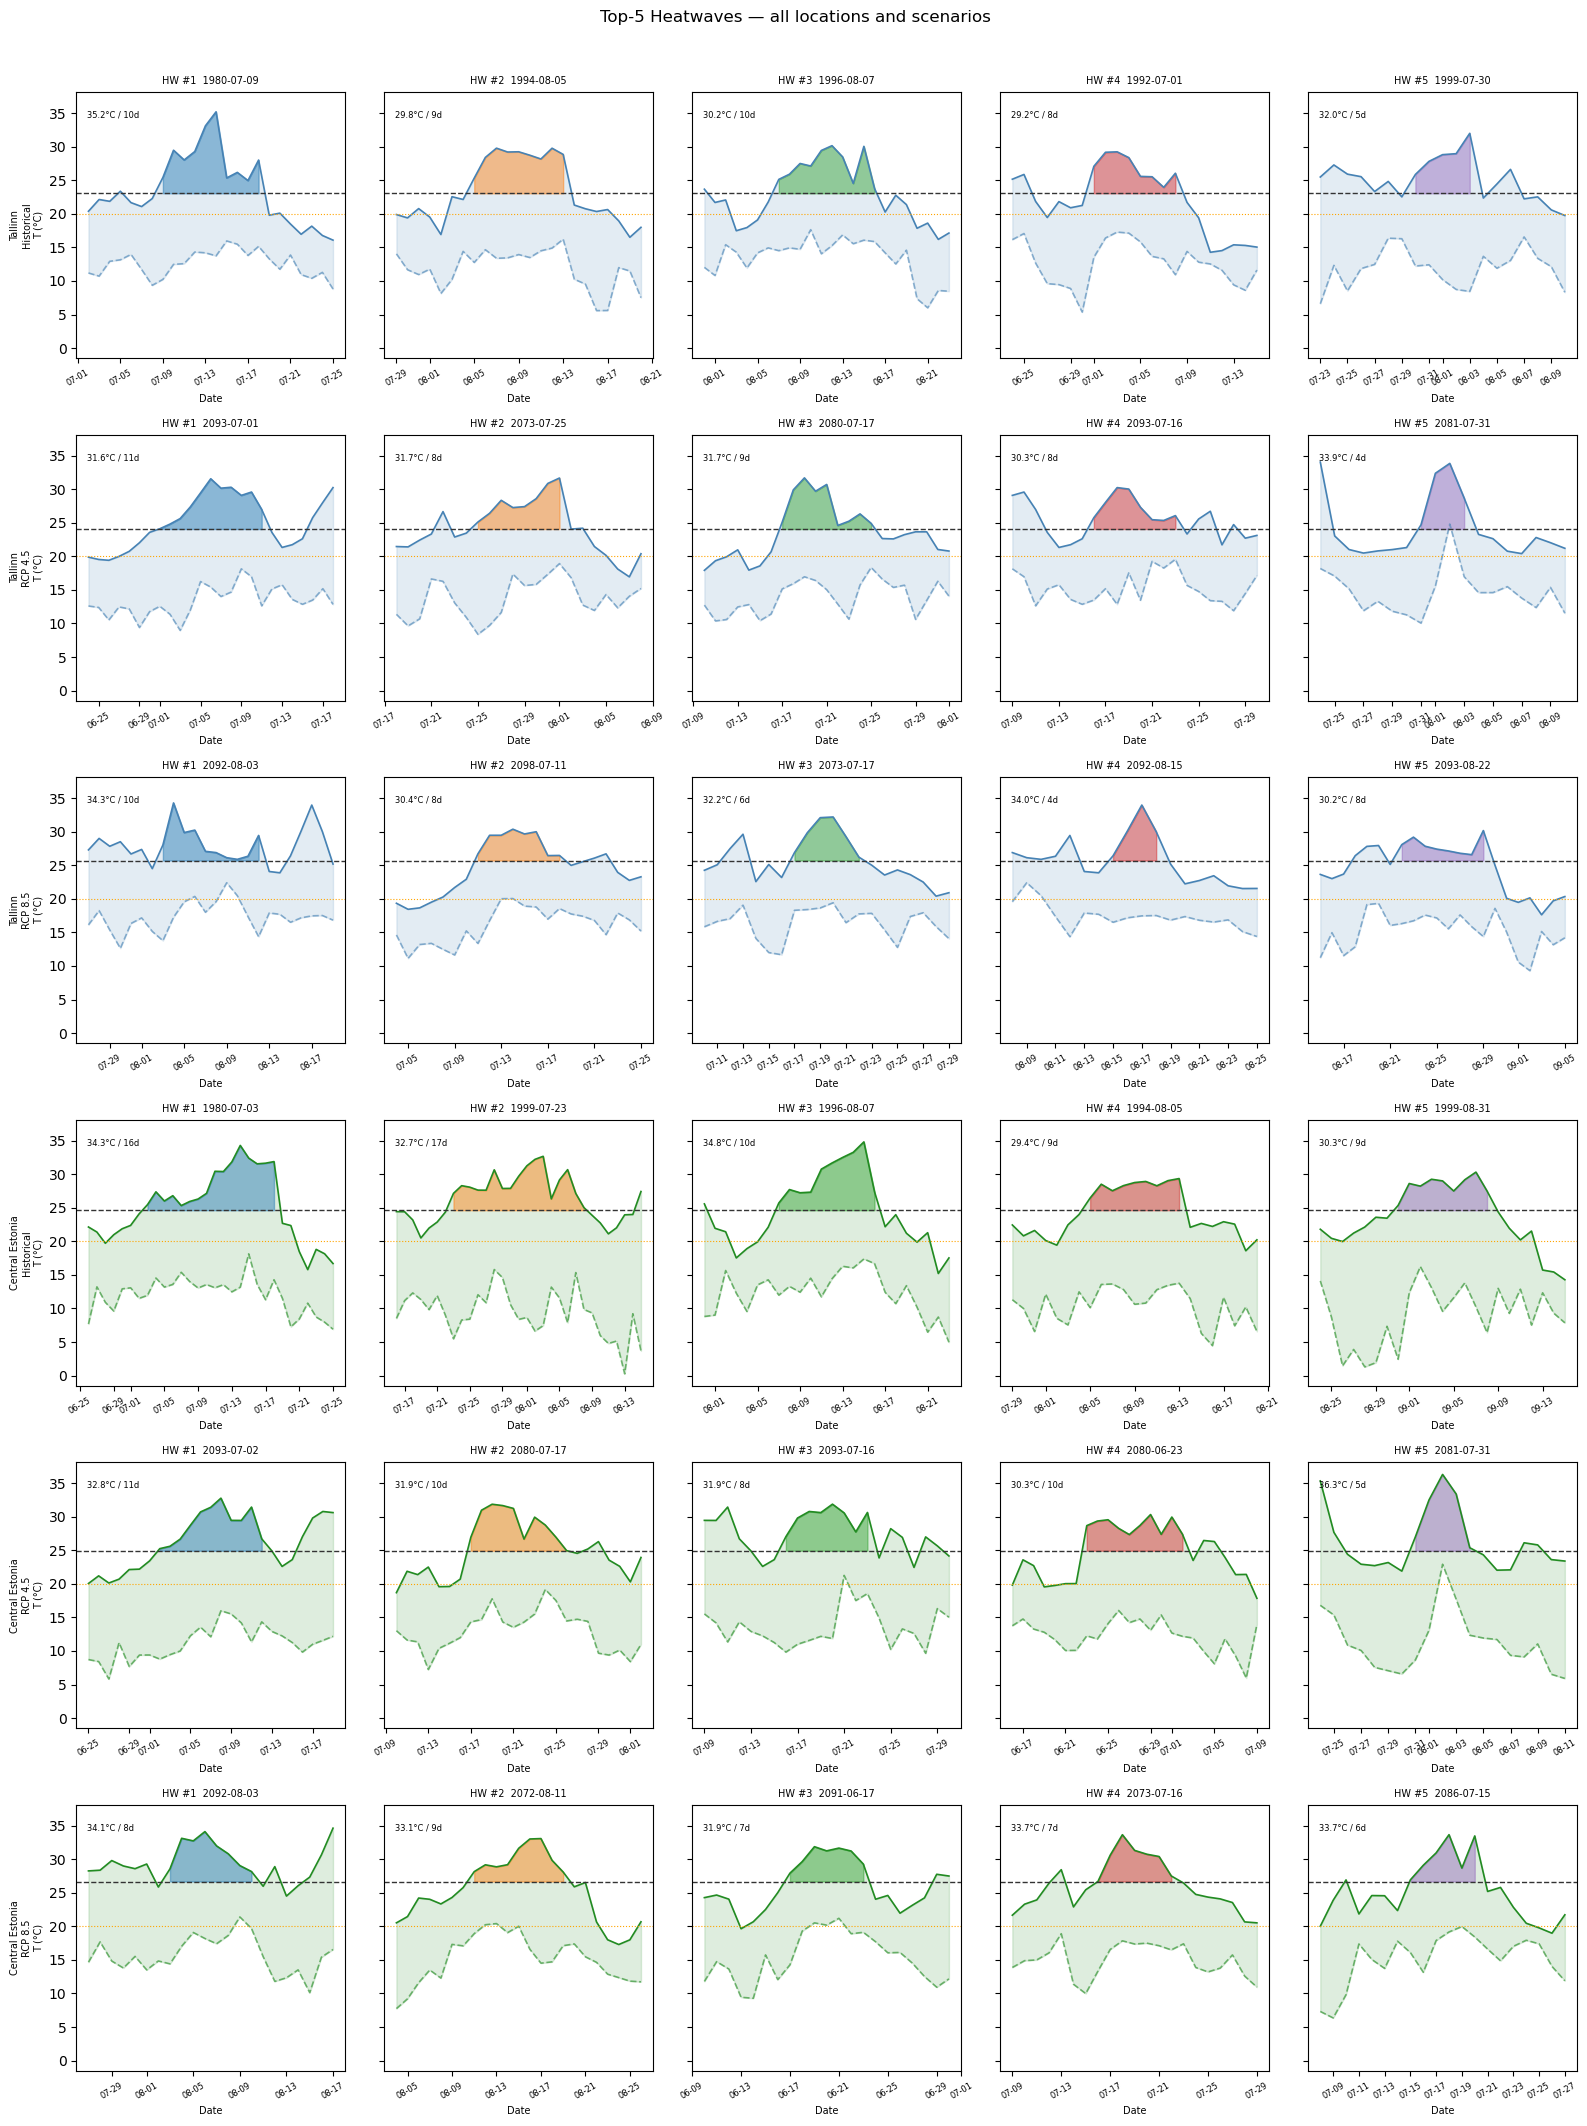

In [9]:
# 4 rows × 5 cols: rows = location × scenario, cols = top-5 events
n_rows = len(LOCATIONS) * len(SCENARIOS)
fig, axes = plt.subplots(n_rows, 5, figsize=(16, n_rows * 3.5), sharey=True)

row_idx = 0
for loc_name, loc_cfg in LOCATIONS.items():
    for scenario, scen_cfg in SCENARIOS.items():
        tmax      = tmax_s[loc_name][scenario]
        tmin      = tmin_s[loc_name][scenario]
        threshold = results[loc_name][scenario]['threshold']
        hw_df     = results[loc_name][scenario]['hw_df']

        for rank, (ax, (_, hw)) in enumerate(zip(axes[row_idx], hw_df.head(5).iterrows()), start=1):
            pad   = pd.Timedelta(days=7)
            win   = (tmax.index >= hw['start'] - pad) & (tmax.index <= hw['end'] + pad)
            spell = (tmax.index >= hw['start']) & (tmax.index <= hw['end'])

            ax.fill_between(tmax.index[win], tmax.values[win], tmin.values[win],
                            alpha=0.15, color=loc_cfg['color'])
            ax.plot(tmax.index[win], tmax.values[win], lw=1.2, color=loc_cfg['color'])
            ax.plot(tmin.index[win], tmin.values[win], lw=1.2, color=loc_cfg['color'],
                    ls='--', alpha=0.6)
            ax.fill_between(tmax.index[spell], tmax.values[spell], threshold,
                            alpha=0.45, color=hw_colors[rank - 1])
            ax.axhline(threshold,     color='#333333', lw=1,   ls='--')
            ax.axhline(ABS_THRESHOLD, color='orange',  lw=0.8, ls=':')
            ax.set_title(f"HW #{rank}  {hw['start'].strftime('%Y-%m-%d')}", fontsize=7)
            ax.set_xlabel('Date', fontsize=7)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
            ax.tick_params(axis='x', labelsize=6, rotation=30)
            ax.set_ylabel('T (°C)' if rank == 1 else '')
            ax.annotate(f"{hw['peak_T_C']:.1f}°C / {hw['duration_days']}d",
                        xy=(0.04, 0.93), xycoords='axes fraction', fontsize=6, va='top')

        # Row label on leftmost panel
        axes[row_idx, 0].set_ylabel(
            f"{loc_cfg['label']}\n{scen_cfg['label']}\nT (°C)", fontsize=7)
        row_idx += 1

fig.suptitle('Top-5 Heatwaves — all locations and scenarios', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
print(f'Abs. threshold: ≥ {ABS_THRESHOLD:.0f} °C  |  Percentile: 90th pct of JJA Tmax\n')

for loc_name, loc_cfg in LOCATIONS.items():
    for scenario, scen_cfg in SCENARIOS.items():
        tmax      = tmax_s[loc_name][scenario]
        threshold = results[loc_name][scenario]['threshold']
        hw_df     = results[loc_name][scenario]['hw_df']
        top5      = results[loc_name][scenario]['top5']
        print(f"=== {loc_cfg['label']} — {scen_cfg['label']}  "
              f"({tmax.index[0].year}–{tmax.index[-1].year}) ===")
        print(f"  threshold={threshold:.2f} °C  |  events={len(hw_df)}")
        print(top5.to_string())
        print()

Abs. threshold: ≥ 20 °C  |  Percentile: 90th pct of JJA Tmax

=== Tallinn — Historical  (1970–2000) ===
  threshold=23.07 °C  |  events=43
        Start         End  Duration (days)  Peak Tmax (°C)  Surplus (°C·days)
1  1980-07-09  1980-07-18               10           35.22              54.41
2  1994-08-05  1994-08-13                9           29.80              49.96
3  1996-08-07  1996-08-16               10           30.17              41.52
4  1992-07-01  1992-07-08                8           29.25              30.48
5  1999-07-30  1999-08-03                5           32.01              28.16

=== Tallinn — RCP 4.5  (2071–2100) ===
  threshold=24.08 °C  |  events=32
        Start         End  Duration (days)  Peak Tmax (°C)  Surplus (°C·days)
1  2093-07-01  2093-07-11               11           31.57              44.24
2  2073-07-25  2073-08-01                8           31.68              33.11
3  2080-07-17  2080-07-25                9           31.70              31.53
4  209

## 4. Climate statistics

In [11]:
# climate_stats is defined in heatwave_utils.py

# Build table: one column per (location, scenario)
LOC_ABBR  = {'tallinn': 'TLN', 'c_estonia': 'EST'}
SCEN_ABBR = {'historical': 'Hist', 'rcp45': 'RCP4.5', 'rcp85': 'RCP8.5'}

cols = {}
for loc_name in LOCATIONS:
    for scenario in SCENARIOS:
        df    = data[loc_name][scenario]
        hw_df = results[loc_name][scenario]['hw_df']
        n_yrs = df.index[-1].year - df.index[0].year + 1
        y0, y1 = df.index[0].year % 100, df.index[-1].year % 100
        col_label = f"{LOC_ABBR[loc_name]}\n{SCEN_ABBR[scenario]}\n{y0:02d}–{y1:02d}"
        cols[col_label] = climate_stats(df, hw_df, n_yrs)

stat_df = pd.DataFrame(cols)
with pd.option_context('display.max_colwidth', 12):
    print(stat_df.to_string(col_space=8))

                       TLN\nHist\n70–00  TLN\nRCP4.5\n71–00  TLN\nRCP8.5\n71–00  EST\nHist\n70–00  EST\nRCP4.5\n71–00  EST\nRCP8.5\n71–00
Tmax mean (°C)                     7.08                9.78               11.19              7.16                9.74               11.20
Tmax JJA (°C)                     18.42               20.07               21.49             19.47               20.66               22.13
Tmax DJF (°C)                     -3.76               -0.13                1.77             -5.19               -1.28                0.87
Tmax record (°C)                  35.22               34.06               34.30             34.83               36.32               35.52
Tmean (°C)                         3.99                7.03                8.58              3.41                6.34                7.97
Tmean JJA (°C)                    14.36               16.51               18.05             14.52               16.23               17.85
Tmean DJF (°C)                    

## 5. Heatwave scatter: mean Tmin vs mean Tmax

Each point is one detected heatwave event. **Colour** = experiment (location × scenario). **Size** = duration in days.

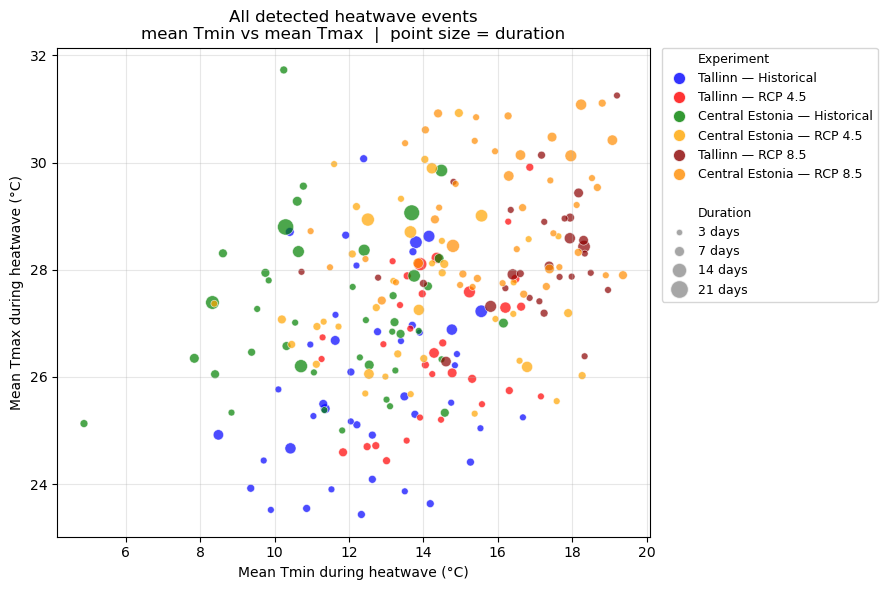

In [12]:
from matplotlib.lines import Line2D

EXP_STYLE = {
    ('tallinn',   'historical'): {'label': 'Tallinn — Historical',        'color': 'blue'},
    ('tallinn',   'rcp45'):      {'label': 'Tallinn — RCP 4.5',           'color': 'red'},
    ('c_estonia', 'historical'): {'label': 'Central Estonia — Historical', 'color': 'green'},
    ('c_estonia', 'rcp45'):      {'label': 'Central Estonia — RCP 4.5',   'color': 'orange'},
    ('tallinn',   'rcp85'):      {'label': 'Tallinn — RCP 8.5',           'color': 'darkred'},
    ('c_estonia', 'rcp85'):      {'label': 'Central Estonia — RCP 8.5',   'color': 'darkorange'},
}

SIZE_SCALE = 8   # marker area (pt²) per day of duration

fig, ax = plt.subplots(figsize=(9, 6))

for (loc_name, scenario), style in EXP_STYLE.items():
    hw_df = results[loc_name][scenario]['hw_df']
    tmax  = tmax_s[loc_name][scenario]
    tmin  = tmin_s[loc_name][scenario]

    xs, ys, sizes = [], [], []
    for _, hw in hw_df.iterrows():
        xs.append(tmin[hw['start']:hw['end']].mean())
        ys.append(tmax[hw['start']:hw['end']].mean())
        sizes.append(hw['duration_days'] * SIZE_SCALE)

    ax.scatter(xs, ys, s=sizes, color=style['color'],
               alpha=0.7, edgecolors='white', linewidths=0.5)

# ── single combined legend, placed to the right of the axes ──────────────────
handles, labels = [], []

# Experiment colour entries
labels.append('Experiment')
handles.append(Line2D([0], [0], linestyle='none'))
for style in EXP_STYLE.values():
    handles.append(Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=style['color'],
                          markeredgecolor='white', markersize=9, alpha=0.8))
    labels.append(style['label'])

# Blank separator row
handles.append(Line2D([0], [0], linestyle='none'))
labels.append('')

# Duration size entries
labels.append('Duration')
handles.append(Line2D([0], [0], linestyle='none'))
for dur in [3, 7, 14, 21]:
    handles.append(Line2D([0], [0], marker='o', color='w',
                          markerfacecolor='grey', markeredgecolor='white',
                          markersize=np.sqrt(dur * SIZE_SCALE), alpha=0.7))
    labels.append(f'{dur} days')

ax.legend(handles, labels,
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,
          fontsize=9, handletextpad=0.5,
          handler_map={Line2D: plt.matplotlib.legend_handler.HandlerLine2D()})

ax.set_xlabel('Mean Tmin during heatwave (°C)')
ax.set_ylabel('Mean Tmax during heatwave (°C)')
ax.set_title('All detected heatwave events\n'
             'mean Tmin vs mean Tmax  |  point size = duration')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()